In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from episbi import SBIEngine
from episbi.models import stochastic_seir
from episbi.prior import UniformPrior
from episbi.metric import evaluate_prediction_windows


/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [2]:
N  = 10000
E0 = 0
I0 = 10
R0 = 0
S0 = N - E0 - I0 - R0

total_days = 100

init_cond = [S0, E0, I0, R0]

In [ ]:
N_JOBS = max(1, (os.cpu_count() or 2) - 1)
DT = 0.01


def _seir_kwargs_from_initial_conditions(initial_conditions):
    s0, e0, i0, r0 = initial_conditions
    return {
        "population": int(round(s0 + e0 + i0 + r0)),
        "initial_exposed": int(round(e0)),
        "initial_infectious": int(round(i0)),
        "initial_recovered": int(round(r0)),
    }


def simulate_stochastic_seir(theta, total_days, initial_conditions, seed=None, dt=DT):
    return stochastic_seir(
        theta,
        total_days=total_days,
        dt=dt,
        seed=seed,
        **_seir_kwargs_from_initial_conditions(initial_conditions),
    )


def _theta_to_dict(theta, names):
    if isinstance(theta, dict):
        return theta
    if hasattr(theta, "detach"):
        theta = theta.detach().cpu().numpy()
    theta = np.asarray(theta, dtype=float)
    return {name: float(theta[i]) for i, name in enumerate(names)}


def _sim_to_array(sim_output):
    arr = sim_output["data"] if isinstance(sim_output, dict) else sim_output
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr[:, None]
    return arr


def _run_one_sim(theta, names, total_days, initial_conditions, seed, dt):
    theta_dict = _theta_to_dict(theta, names)
    sim = simulate_stochastic_seir(
        theta_dict,
        total_days=total_days,
        initial_conditions=initial_conditions,
        seed=int(seed),
        dt=dt,
    )
    return _sim_to_array(sim)[:total_days]


def simulate_for_sbi_parallel(
    prior,
    num_simulations,
    total_days,
    initial_conditions,
    seed=0,
    dt=DT,
    n_jobs=N_JOBS,
):
    rng = np.random.default_rng(seed)
    names = list(prior.names)
    low = np.asarray(prior.low, dtype=np.float32)
    high = np.asarray(prior.high, dtype=np.float32)
    thetas = rng.uniform(low, high, size=(num_simulations, len(names))).astype(np.float32)
    sim_seeds = rng.integers(0, 2**32 - 1, size=num_simulations, dtype=np.uint32)

    xs = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
        delayed(_run_one_sim)(theta, names, total_days, initial_conditions, sim_seed, dt)
        for theta, sim_seed in zip(thetas, sim_seeds)
    )
    return thetas, np.stack(xs).astype(np.float32)


def posterior_predictive_parallel(
    samples,
    prior,
    total_days,
    initial_conditions,
    n_samples=300,
    seed=12345,
    dt=DT,
    n_jobs=N_JOBS,
):
    selected = np.asarray(samples[:n_samples], dtype=np.float32)
    rng = np.random.default_rng(seed)
    sim_seeds = rng.integers(0, 2**32 - 1, size=len(selected), dtype=np.uint32)
    names = list(prior.names)

    sims = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
        delayed(_run_one_sim)(theta, names, total_days, initial_conditions, sim_seed, dt)
        for theta, sim_seed in zip(selected, sim_seeds)
    )
    return np.stack(sims).astype(np.float32)


print(f"Parallel simulations: n_jobs={N_JOBS}, dt={DT}")


In [3]:
prior = UniformPrior(
    bounds={
        "beta": (0.8, 0.8),
        "kappa": (0.3, 0.3),
        "gamma": (0.35, 0.35),
    }
)

In [4]:
thetas, xs = simulate_for_sbi_parallel(
    prior=prior,
    num_simulations=100,
    total_days=total_days,
    seed=0,
    initial_conditions=init_cond,
)


In [5]:
q025,q975=np.quantile(xs.squeeze(-1), [0.025, 0.975], axis=0)

In [6]:
true_theta = {"beta": 0.80, "kappa": 0.3, "gamma": 0.35}
observed = simulate_stochastic_seir(
    true_theta,
    total_days=total_days,
    initial_conditions=init_cond,
    seed=0,
)["data"]


Text(0, 0.5, 'Cases')

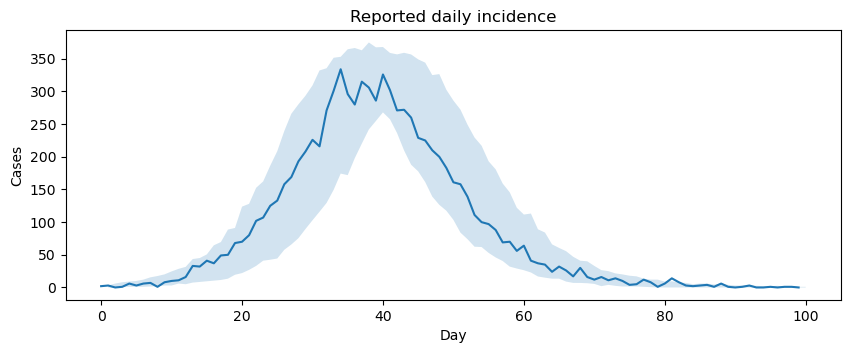

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.fill_between(np.arange(1,101), q025, q975, alpha=0.2,label="95% interval fit")
ax.plot(observed[:, 0])
ax.set_title("Reported daily incidence")
ax.set_xlabel("Day")
ax.set_ylabel("Cases")

## Inference - NPE

In [10]:
inference_days = 100
forecast_days = 0

In [12]:
prior = UniformPrior(
    bounds={
        "beta": (0.01, 1.5),
        "kappa": (0.01, 0.5),
        "gamma": (0.01, 0.5),
    }
)

In [13]:
thetas, xs = simulate_for_sbi_parallel(
    prior=prior,
    num_simulations=1000,
    total_days=total_days,
    seed=0,
    initial_conditions=init_cond,
)


In [14]:
thetas_train=thetas
xs_train=xs[:,:inference_days]
obs_train = observed[:inference_days]

In [15]:
engine = SBIEngine(batch_size=256)
npe_result = engine.run_npe(
    obs_data=obs_train.squeeze(-1),
    prior=prior,
    thetas=thetas_train,
    xs=xs_train.squeeze(-1),
    input_dim=1,
    num_samples=1000,
    show_train_summary=False,
)

[*] Running NPE (use_lstm=False) with batch size 256...
 Neural network successfully converged after 146 epochs.

1039it [00:00, 62233.23it/s]            


In [16]:
_, samples = npe_result

In [17]:
posterior_samples = samples

param_df = pd.DataFrame(posterior_samples, columns=prior.names)
param_df.describe()

,beta,kappa,gamma
count,1000.000000,1000.000000,1000.000000
mean,0.813618,0.249700,0.283902
std,0.261505,0.099640,0.106448
min,0.172338,0.051863,0.012787
25%,0.622003,0.171782,0.209168
50%,0.816752,0.239900,0.287842
75%,1.004314,0.318025,0.366850
max,1.494343,0.499099,0.499773


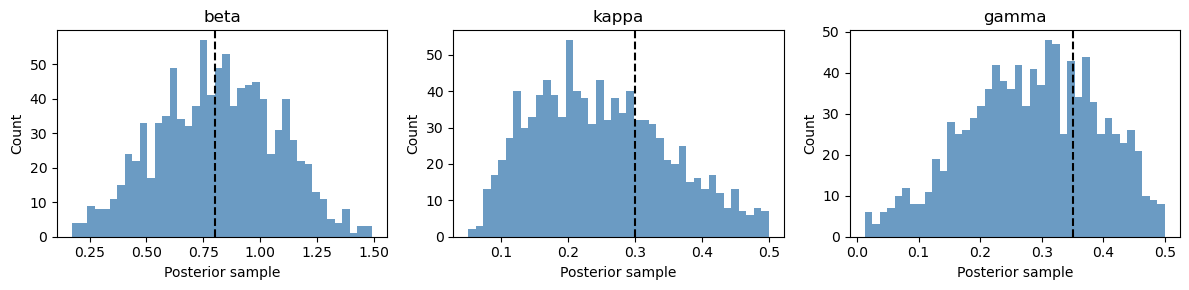

In [18]:
fig, axes = plt.subplots(1, len(prior.names), figsize=(4 * len(prior.names), 3))

if len(prior.names) == 1:
    axes = [axes]

for ax, name in zip(axes, prior.names):
    ax.hist(param_df[name], bins=40, color="steelblue", alpha=0.8)
    ax.axvline(true_theta[name], color="black", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Posterior sample")
    ax.set_ylabel("Count")

fig.tight_layout()

In [ ]:
posterior_predictive = posterior_predictive_parallel(
    posterior_samples,
    prior=prior,
    total_days=total_days,
    initial_conditions=init_cond,
    n_samples=300,
    seed=2024,
)

posterior_predictive.shape


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

for i in range(min(100, posterior_predictive.shape[0])):
    ax.plot(
        posterior_predictive[i, :, 0],
        color="steelblue",
        alpha=0.08,
        linewidth=1,
    )

ax.plot(observed[:, 0], color="black", linewidth=2, label="Observed")
ax.axvline(inference_days - 0.5, color="gray", linestyle=":")
ax.set_xlabel("Day")
ax.set_ylabel("Incidence")
ax.set_title("Posterior predictive trajectories")
ax.legend(frameon=False)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

plot_prediction_windows(
    observed,
    posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    ylabel="Incidence",
    title="Posterior predictive evaluation",
    ax=ax,
)

fig.tight_layout()

In [ ]:
ppc_result = evaluate_prediction_windows(
    y_obs=observed,
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_names=["incidence"],
)

ppc_result